# 07 — Robustness Analysis and Thesis Results

This notebook aggregates the outputs from Notebooks 4–6 across the four experiments:

- `monthly_ff3`
- `monthly_ff5`
- `daily_ff3`
- `daily_ff5`

It creates thesis-ready comparison tables, robustness tests, cumulative-wealth charts, model rankings, and an automatically generated results summary. Missing experiments are skipped without stopping the notebook.

In [1]:
from pathlib import Path
import re
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from IPython.display import display, Markdown

warnings.filterwarnings("ignore")
pd.set_option("display.max_columns", 100)
pd.set_option("display.float_format", lambda x: f"{x:,.4f}")

In [2]:
EXPERIMENTS = [
    "monthly_ff3",
    "monthly_ff5",
    "daily_ff3",
    "daily_ff5",
]

EXPERIMENT_LABELS = {
    "monthly_ff3": "Monthly FF3",
    "monthly_ff5": "Monthly FF5",
    "daily_ff3": "Daily FF3",
    "daily_ff5": "Daily FF5",
}

MODEL_ROOT = Path("../models")
RESULT_ROOT = Path("../results")
OUTPUT_DIR = RESULT_ROOT / "robustness_analysis"
FIGURE_DIR = OUTPUT_DIR / "figures"
TABLE_DIR = OUTPUT_DIR / "tables"

FIGURE_DIR.mkdir(parents=True, exist_ok=True)
TABLE_DIR.mkdir(parents=True, exist_ok=True)

print("Output directory:", OUTPUT_DIR.resolve())

Output directory: C:\Users\kyler\Documents\VS_Code\Finance Code\ML using FAMA and FRENCH\results\robustness_analysis


## 1. Check available experiment outputs

In [3]:
availability_rows = []

for experiment in EXPERIMENTS:
    files = {
        "model_results": MODEL_ROOT / experiment / "final_model_results.csv",
        "model_comparison": RESULT_ROOT / experiment / "model_comparison_enriched.csv",
        "top_k": RESULT_ROOT / experiment / "top_k_summary.csv",
        "performance": RESULT_ROOT / experiment / "backtest" / "performance_summary.csv",
        "benchmark": RESULT_ROOT / experiment / "backtest" / "equal_weight_benchmark.csv",
    }

    row = {
        "Experiment": experiment,
        "Label": EXPERIMENT_LABELS[experiment],
    }
    row.update({name: path.exists() for name, path in files.items()})
    row["Complete"] = all(row[name] for name in files)
    availability_rows.append(row)

availability = pd.DataFrame(availability_rows)
display(availability)
availability.to_csv(TABLE_DIR / "experiment_availability.csv", index=False)

AVAILABLE_EXPERIMENTS = availability.loc[
    availability["Complete"], "Experiment"
].tolist()

print("Complete experiments:", AVAILABLE_EXPERIMENTS)

missing = [x for x in EXPERIMENTS if x not in AVAILABLE_EXPERIMENTS]
if missing:
    print("Missing or incomplete experiments:", missing)

,Experiment,Label,model_results,model_comparison,top_k,performance,benchmark,Complete
0,monthly_ff3,Monthly FF3,True,True,True,True,True,True
1,monthly_ff5,Monthly FF5,True,True,True,True,True,True
2,daily_ff3,Daily FF3,True,True,True,True,True,True
3,daily_ff5,Daily FF5,True,True,True,True,True,True


Complete experiments: ['monthly_ff3', 'monthly_ff5', 'daily_ff3', 'daily_ff5']


## 2. Load and standardize classification results

In [4]:
def normalize_model_columns(df):
    df = df.copy()

    if "model" not in df.columns and "Model" in df.columns:
        df = df.rename(columns={"Model": "model"})

    df["model"] = (
        df["model"]
        .astype(str)
        .str.replace(" — Test", "", regex=False)
        .str.replace(" - Test", "", regex=False)
    )

    if "architecture" not in df.columns:
        df["architecture"] = df["model"].str.extract(
            r"^(XGBoost|CNN|Ensemble)", expand=False
        )

    if "feature_type" not in df.columns:
        df["feature_type"] = df["model"].str.extract(
            r"(Signature|GARCH|Combined)$", expand=False
        )

    rename_map = {
        "accuracy": "Accuracy",
        "precision": "Precision",
        "recall": "Recall",
        "f1": "F1",
        "roc_auc": "ROC_AUC",
        "threshold": "Threshold",
    }
    df = df.rename(columns={k: v for k, v in rename_map.items() if k in df.columns})
    return df

classification_frames = []

for experiment in AVAILABLE_EXPERIMENTS:
    enriched_path = RESULT_ROOT / experiment / "model_comparison_enriched.csv"
    fallback_path = MODEL_ROOT / experiment / "final_model_results.csv"
    source_path = enriched_path if enriched_path.exists() else fallback_path

    frame = normalize_model_columns(pd.read_csv(source_path))
    frame.insert(0, "Experiment", experiment)
    frame.insert(1, "Dataset", EXPERIMENT_LABELS[experiment])
    frame["Frequency"] = np.where(frame["Experiment"].str.startswith("monthly"), "Monthly", "Daily")
    frame["Factor Model"] = np.where(frame["Experiment"].str.endswith("ff3"), "FF3", "FF5")
    classification_frames.append(frame)

classification_results = (
    pd.concat(classification_frames, ignore_index=True)
    if classification_frames
    else pd.DataFrame()
)

if classification_results.empty:
    print("No complete classification results are available yet.")
else:
    preferred = [
        "Experiment", "Dataset", "Frequency", "Factor Model",
        "architecture", "feature_type", "model",
        "Accuracy", "Precision", "Recall", "F1", "ROC_AUC", "Threshold"
    ]
    ordered = [c for c in preferred if c in classification_results.columns]
    remaining = [c for c in classification_results.columns if c not in ordered]
    classification_results = classification_results[ordered + remaining]
    classification_results.to_csv(TABLE_DIR / "all_classification_results.csv", index=False)
    display(classification_results.head(20))

,Experiment,Dataset,Frequency,Factor Model,architecture,feature_type,model,Accuracy,Precision,Recall,F1,ROC_AUC,Threshold
0,monthly_ff3,Monthly FF3,Monthly,FF3,XGBoost,Signature,XGBoost Signature,0.2119,0.2009,0.9876,0.3339,0.5037,0.3100
1,monthly_ff3,Monthly FF3,Monthly,FF3,Ensemble,Signature,Ensemble Signature,0.2126,0.2009,0.9865,0.3338,0.5034,0.3400
2,monthly_ff3,Monthly FF3,Monthly,FF3,XGBoost,Combined,XGBoost Combined,0.2011,0.2002,1.0000,0.3336,0.5009,0.2200
3,monthly_ff3,Monthly FF3,Monthly,FF3,CNN,NaN,CNN Garch,0.2000,0.2000,1.0000,0.3333,0.4980,0.0500
4,monthly_ff3,Monthly FF3,Monthly,FF3,XGBoost,NaN,XGBoost Garch,0.2000,0.2000,1.0000,0.3333,0.4954,0.1300
5,monthly_ff3,Monthly FF3,Monthly,FF3,Ensemble,NaN,Ensemble Garch,0.2000,0.2000,1.0000,0.3333,0.4953,0.2300
6,monthly_ff3,Monthly FF3,Monthly,FF3,CNN,Combined,CNN Combined,0.2180,0.2006,0.9753,0.3328,0.4879,0.4600
7,monthly_ff3,Monthly FF3,Monthly,FF3,Ensemble,Combined,Ensemble Combined,0.2180,0.2006,0.9753,0.3328,0.4879,0.4600
8,monthly_ff3,Monthly FF3,Monthly,FF3,CNN,Signature,CNN Signature,0.2002,0.1994,0.9944,0.3321,0.5038,0.4500
9,monthly_ff5,Monthly FF5,Monthly,FF5,CNN,Combined,CNN Combined,0.2082,0.2010,0.9946,0.3344,0.4811,0.4800


## 3. Load portfolio-backtest results

In [5]:
performance_frames = []

for experiment in AVAILABLE_EXPERIMENTS:
    path = RESULT_ROOT / experiment / "backtest" / "performance_summary.csv"
    frame = pd.read_csv(path)
    frame.insert(0, "Experiment", experiment)
    frame.insert(1, "Dataset", EXPERIMENT_LABELS[experiment])
    frame["Frequency"] = np.where(frame["Experiment"].str.startswith("monthly"), "Monthly", "Daily")
    frame["Factor Model"] = np.where(frame["Experiment"].str.endswith("ff3"), "FF3", "FF5")

    frame["architecture"] = frame["Model"].str.extract(
        r"^(XGBoost|CNN|Ensemble)", expand=False
    )
    frame["feature_type"] = frame["Model"].str.extract(
        r"(Signature|GARCH|Combined)$", expand=False
    )
    frame["Is Benchmark"] = frame["Model"].eq("Equal-Weight 25 Portfolios")
    performance_frames.append(frame)

performance_results = (
    pd.concat(performance_frames, ignore_index=True)
    if performance_frames
    else pd.DataFrame()
)

if performance_results.empty:
    print("No complete backtest results are available yet.")
else:
    performance_results.to_csv(TABLE_DIR / "all_backtest_results.csv", index=False)
    display(performance_results.head(20))

,Experiment,Dataset,Model,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown,Frequency,Factor Model,architecture,feature_type,Is Benchmark
0,monthly_ff3,Monthly FF3,CNN GARCH,5.8228,0.1382,0.1811,0.8078,-0.2351,Monthly,FF3,CNN,GARCH,False
1,monthly_ff3,Monthly FF3,CNN Signature,5.4384,0.1338,0.1893,0.7606,-0.3167,Monthly,FF3,CNN,Signature,False
2,monthly_ff3,Monthly FF3,Ensemble Signature,5.3198,0.1323,0.1994,0.7278,-0.3900,Monthly,FF3,Ensemble,Signature,False
3,monthly_ff3,Monthly FF3,XGBoost Signature,5.3039,0.1322,0.1994,0.7270,-0.3900,Monthly,FF3,XGBoost,Signature,False
4,monthly_ff3,Monthly FF3,XGBoost GARCH,4.8150,0.1260,0.1932,0.7142,-0.3436,Monthly,FF3,XGBoost,GARCH,False
5,monthly_ff3,Monthly FF3,Equal-Weight 25 Portfolios,4.3521,0.1197,0.1831,0.7122,-0.3083,Monthly,FF3,NaN,NaN,True
6,monthly_ff3,Monthly FF3,Ensemble GARCH,4.5503,0.1225,0.1930,0.6985,-0.3538,Monthly,FF3,Ensemble,GARCH,False
7,monthly_ff3,Monthly FF3,XGBoost Combined,4.6039,0.1232,0.2008,0.6835,-0.4135,Monthly,FF3,XGBoost,Combined,False
8,monthly_ff3,Monthly FF3,CNN Combined,3.2296,0.1021,0.1931,0.6024,-0.3637,Monthly,FF3,CNN,Combined,False
9,monthly_ff3,Monthly FF3,Ensemble Combined,3.2296,0.1021,0.1931,0.6024,-0.3637,Monthly,FF3,Ensemble,Combined,False


## 4. Overall model-ranking tables

In [6]:
if not classification_results.empty:
    metric_sort = [c for c in ["F1", "ROC_AUC", "Accuracy"] if c in classification_results.columns]
    best_classification = (
        classification_results
        .sort_values(metric_sort, ascending=False)
        .groupby("Experiment", as_index=False)
        .first()
    )

    best_columns = [
        "Dataset", "architecture", "feature_type", "model",
        "Accuracy", "F1", "ROC_AUC", "Threshold"
    ]
    best_columns = [c for c in best_columns if c in best_classification.columns]
    best_classification = best_classification[best_columns]
    best_classification.to_csv(TABLE_DIR / "best_classifier_by_experiment.csv", index=False)

    display(Markdown("### Best classifier in each experiment"))
    display(best_classification)

    ranking = classification_results.copy()
    for metric in ["Accuracy", "F1", "ROC_AUC"]:
        if metric in ranking.columns:
            ranking[f"Rank_{metric}"] = ranking.groupby("Experiment")[metric].rank(
                ascending=False, method="min"
            )

    rank_columns = [c for c in ranking.columns if c.startswith("Rank_")]
    ranking["Mean Metric Rank"] = ranking[rank_columns].mean(axis=1)
    overall_model_ranking = (
        ranking.groupby(["architecture", "feature_type"], as_index=False)
        .agg(
            Mean_Rank=("Mean Metric Rank", "mean"),
            Mean_Accuracy=("Accuracy", "mean"),
            Mean_F1=("F1", "mean"),
            Mean_ROC_AUC=("ROC_AUC", "mean"),
            Experiments=("Experiment", "nunique"),
        )
        .sort_values(["Mean_Rank", "Mean_F1"])
    )
    overall_model_ranking.to_csv(TABLE_DIR / "overall_model_ranking.csv", index=False)

    display(Markdown("### Average model ranking across available experiments"))
    display(overall_model_ranking)

### Best classifier in each experiment

,Dataset,architecture,feature_type,model,Accuracy,F1,ROC_AUC,Threshold
0,Daily FF3,XGBoost,Signature,XGBoost Signature,0.2008,0.3334,0.5212,0.3400
1,Daily FF5,CNN,Combined,CNN Combined,0.2002,0.3334,0.5152,0.3700
2,Monthly FF3,XGBoost,Signature,XGBoost Signature,0.2119,0.3339,0.5037,0.3100
3,Monthly FF5,CNN,Combined,CNN Combined,0.2082,0.3344,0.4811,0.4800


### Average model ranking across available experiments

,architecture,feature_type,Mean_Rank,Mean_Accuracy,Mean_F1,Mean_ROC_AUC,Experiments
3,Ensemble,Signature,3.0833,0.2100,0.3328,0.5127,4
5,XGBoost,Signature,3.6667,0.2078,0.3328,0.5116,4
2,Ensemble,Combined,4.5833,0.2081,0.3333,0.5007,4
4,XGBoost,Combined,4.6667,0.2031,0.3331,0.5106,4
0,CNN,Combined,4.8333,0.2077,0.3334,0.4999,4
1,CNN,Signature,5.2500,0.2023,0.3328,0.5089,4


## 5. Best portfolio strategy in each experiment

In [7]:
if not performance_results.empty:
    strategies_only = performance_results.loc[~performance_results["Is Benchmark"]].copy()

    best_strategy = (
        strategies_only
        .sort_values(["Sharpe Ratio", "Annualized Return"], ascending=False)
        .groupby("Experiment", as_index=False)
        .first()
    )

    best_strategy_columns = [
        "Dataset", "Model", "architecture", "feature_type",
        "Total Return", "Annualized Return", "Annualized Volatility",
        "Sharpe Ratio", "Maximum Drawdown"
    ]
    best_strategy = best_strategy[best_strategy_columns]
    best_strategy.to_csv(TABLE_DIR / "best_strategy_by_experiment.csv", index=False)

    display(best_strategy)

    strategy_ranking = (
        strategies_only.groupby(["architecture", "feature_type"], as_index=False)
        .agg(
            Mean_Annualized_Return=("Annualized Return", "mean"),
            Mean_Sharpe=("Sharpe Ratio", "mean"),
            Mean_Max_Drawdown=("Maximum Drawdown", "mean"),
            Experiments=("Experiment", "nunique"),
        )
        .sort_values(["Mean_Sharpe", "Mean_Annualized_Return"], ascending=False)
    )
    strategy_ranking.to_csv(TABLE_DIR / "overall_strategy_ranking.csv", index=False)

    display(Markdown("### Average strategy performance across available experiments"))
    display(strategy_ranking)

,Dataset,Model,architecture,feature_type,Total Return,Annualized Return,Annualized Volatility,Sharpe Ratio,Maximum Drawdown
0,Daily FF3,XGBoost Signature,XGBoost,Signature,4.9832,0.1216,0.2311,0.6126,-0.4184
1,Daily FF5,CNN Signature,CNN,Signature,1.8075,0.1162,0.2485,0.5674,-0.4019
2,Monthly FF3,CNN GARCH,CNN,GARCH,5.8228,0.1382,0.1811,0.8078,-0.2351
3,Monthly FF5,Ensemble Signature,Ensemble,Signature,2.2018,0.1328,0.2015,0.7217,-0.2840


### Average strategy performance across available experiments

,architecture,feature_type,Mean_Annualized_Return,Mean_Sharpe,Mean_Max_Drawdown,Experiments
1,CNN,GARCH,0.1215,0.6367,-0.3641,4
2,CNN,Signature,0.1201,0.6308,-0.3798,4
8,XGBoost,Signature,0.1169,0.6259,-0.3854,4
5,Ensemble,Signature,0.1134,0.6104,-0.3862,4
6,XGBoost,Combined,0.1158,0.6039,-0.4178,4
7,XGBoost,GARCH,0.1130,0.6032,-0.4002,4
4,Ensemble,GARCH,0.1109,0.5921,-0.4018,4
0,CNN,Combined,0.1029,0.5552,-0.3827,4
3,Ensemble,Combined,0.1028,0.5542,-0.3880,4


## 6. Classification metric charts

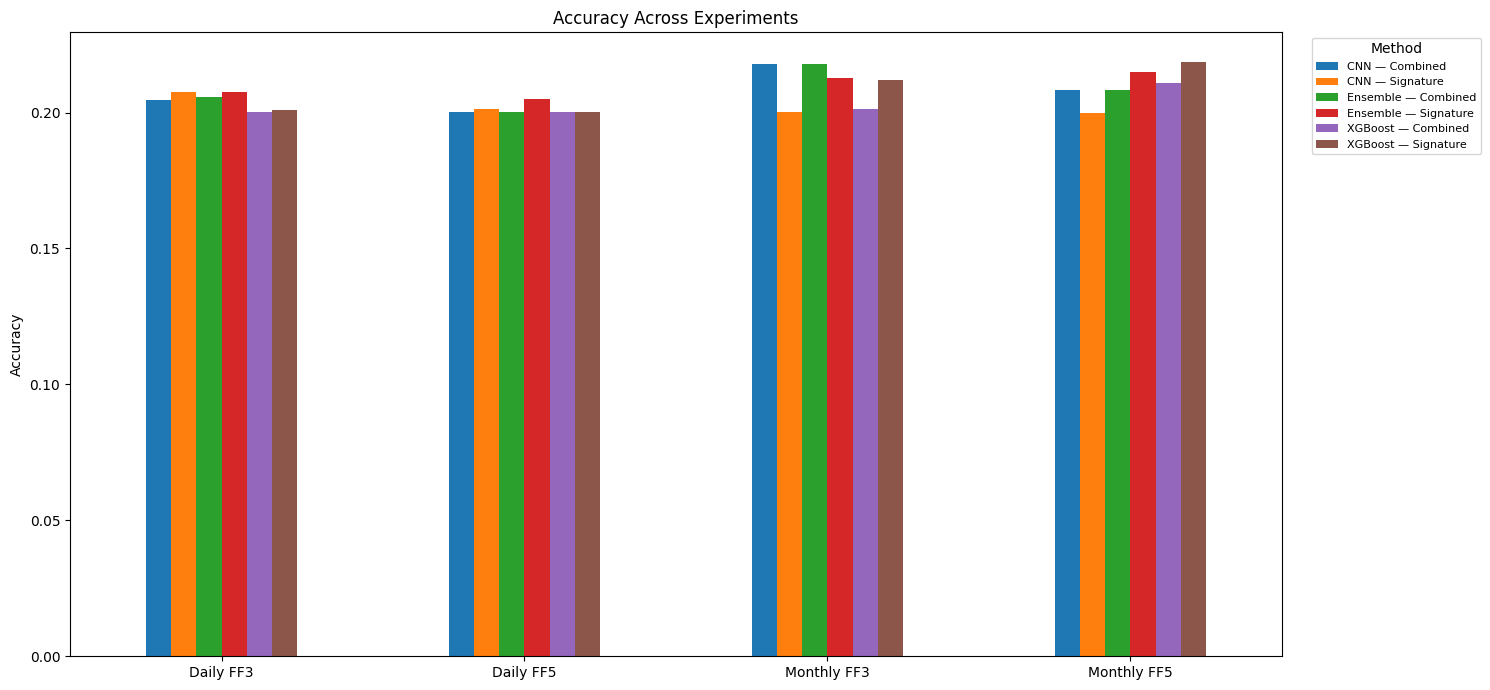

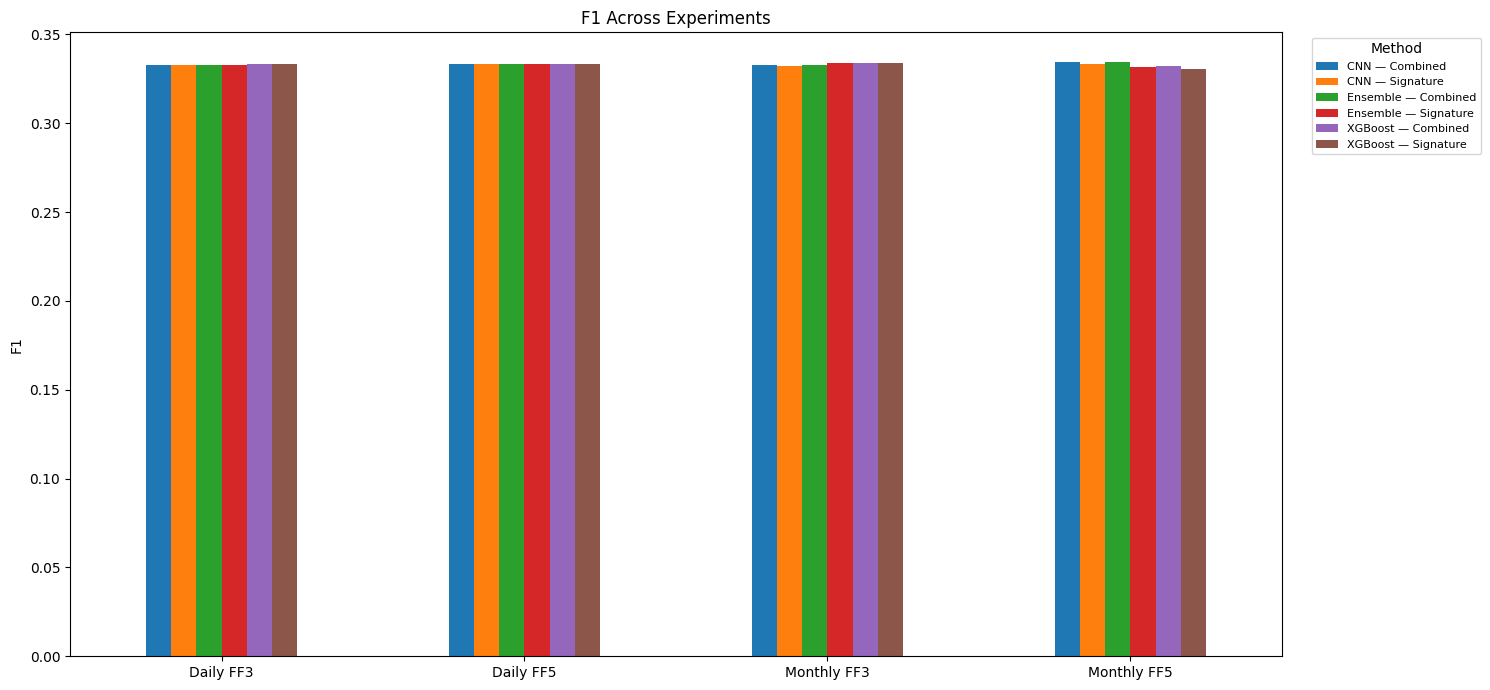

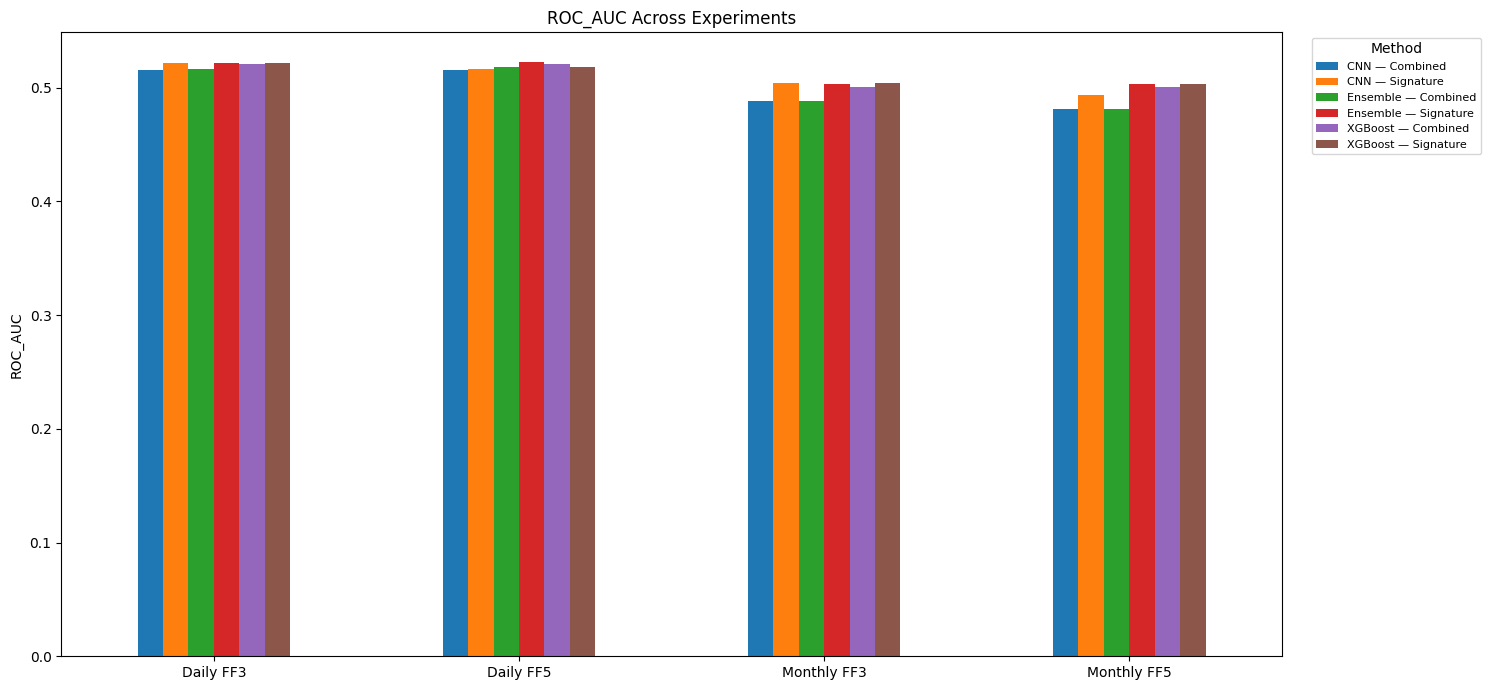

In [8]:
def grouped_metric_plot(df, metric, filename):
    if df.empty or metric not in df.columns:
        return

    plot_df = df.copy()
    plot_df["Method"] = plot_df["architecture"] + " — " + plot_df["feature_type"]
    pivot = plot_df.pivot_table(
        index="Dataset", columns="Method", values=metric, aggfunc="mean"
    )

    ax = pivot.plot(kind="bar", figsize=(15, 7))
    ax.set_title(f"{metric} Across Experiments")
    ax.set_xlabel("")
    ax.set_ylabel(metric)
    ax.tick_params(axis="x", rotation=0)
    ax.legend(title="Method", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / filename, dpi=250, bbox_inches="tight")
    plt.show()

for metric, filename in [
    ("Accuracy", "classification_accuracy.png"),
    ("F1", "classification_f1.png"),
    ("ROC_AUC", "classification_roc_auc.png"),
]:
    grouped_metric_plot(classification_results, metric, filename)

## 7. Signature vs GARCH vs Combined robustness

,Dataset,feature_type,Accuracy,F1,ROC_AUC
0,Daily FF3,Combined,0.2035,0.3330,0.5175
1,Daily FF3,Signature,0.2053,0.3329,0.5215
2,Daily FF5,Combined,0.2002,0.3333,0.5179
3,Daily FF5,Signature,0.2020,0.3333,0.5190
4,Monthly FF3,Combined,0.2124,0.3331,0.4922
5,Monthly FF3,Signature,0.2082,0.3333,0.5036
6,Monthly FF5,Combined,0.2090,0.3337,0.4874
7,Monthly FF5,Signature,0.2112,0.3318,0.5001


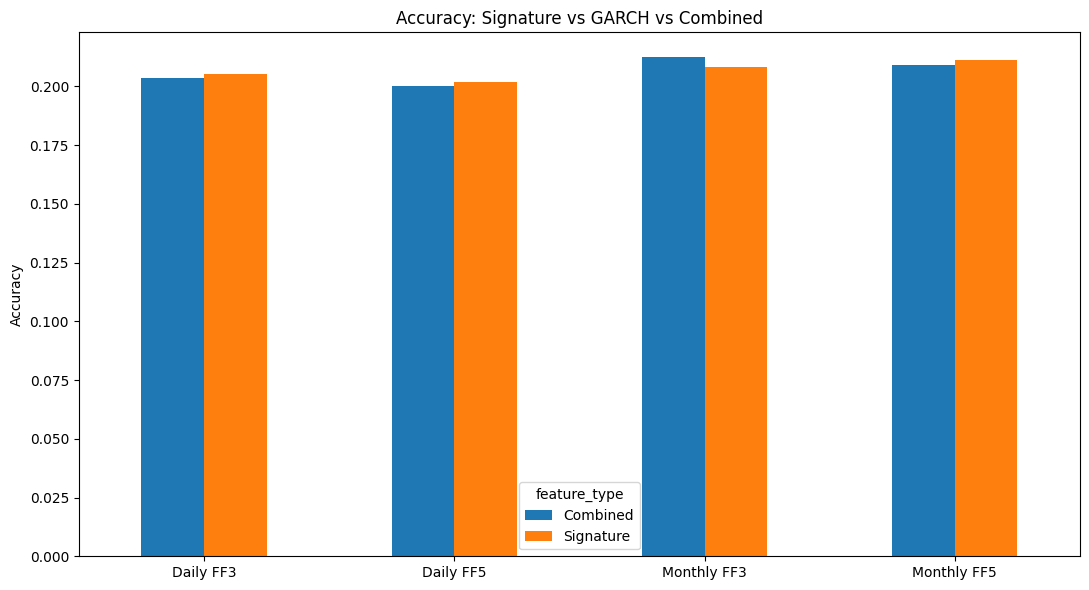

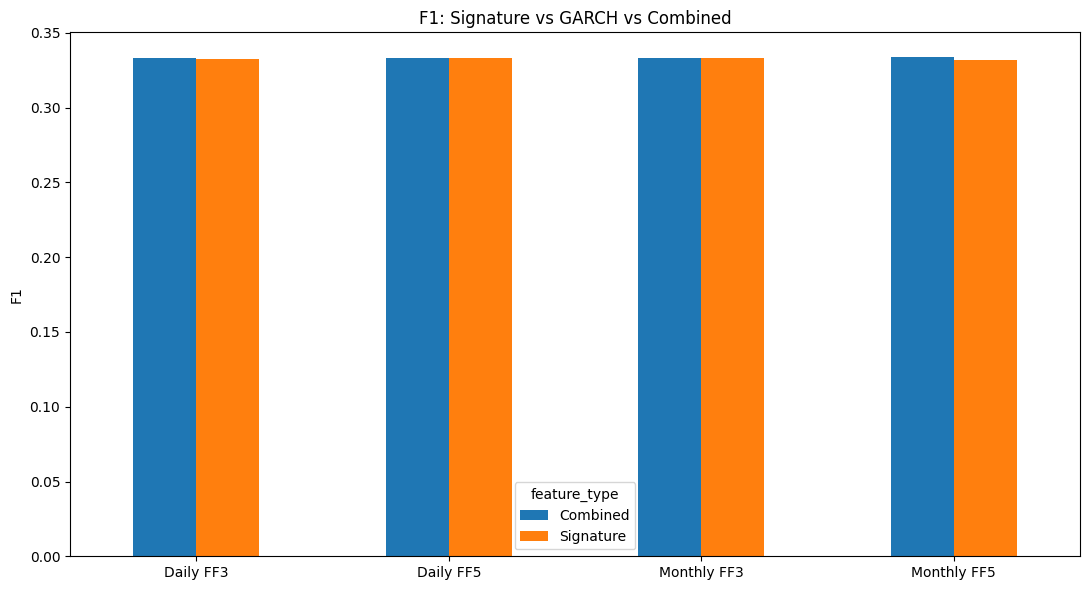

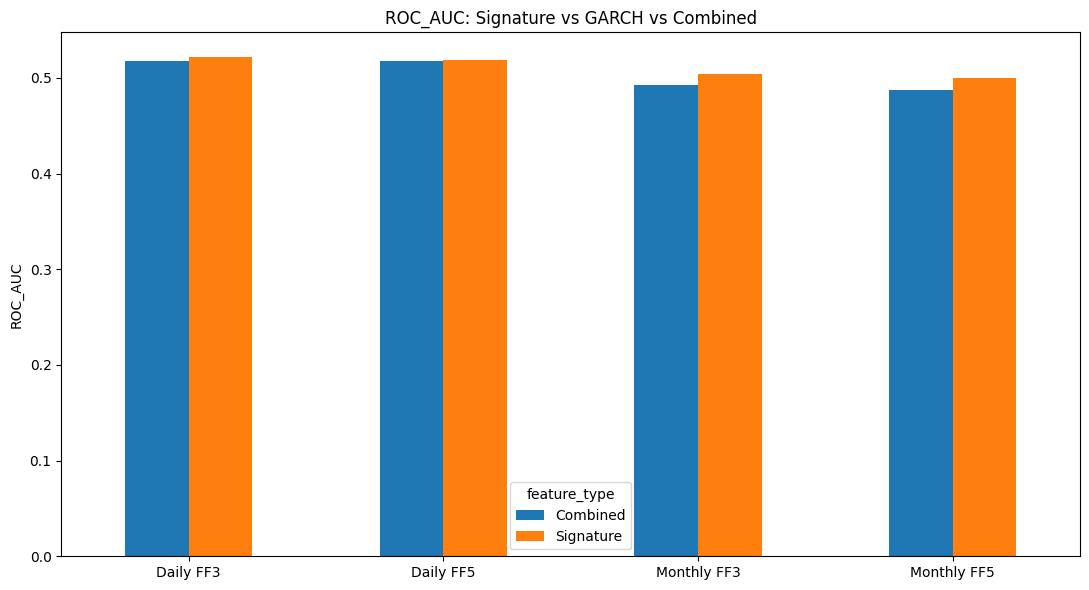

,Dataset,feature_type,Annualized_Return,Sharpe_Ratio,Maximum_Drawdown
0,Daily FF3,Combined,0.1114,0.5538,-0.4585
1,Daily FF3,GARCH,0.1120,0.5648,-0.4689
2,Daily FF3,Signature,0.1155,0.5856,-0.4365
3,Daily FF5,Combined,0.0806,0.4281,-0.4468
4,Daily FF5,GARCH,0.1074,0.5264,-0.4379
5,Daily FF5,Signature,0.0919,0.4803,-0.4254
6,Monthly FF3,Combined,0.1091,0.6295,-0.3803
7,Monthly FF3,GARCH,0.1289,0.7402,-0.3108
8,Monthly FF3,Signature,0.1328,0.7385,-0.3655
9,Monthly FF5,Combined,0.1275,0.6731,-0.2991


In [9]:
if not classification_results.empty:
    feature_comparison = (
        classification_results.groupby(["Dataset", "feature_type"], as_index=False)
        .agg(
            Accuracy=("Accuracy", "mean"),
            F1=("F1", "mean"),
            ROC_AUC=("ROC_AUC", "mean"),
        )
    )
    feature_comparison.to_csv(TABLE_DIR / "feature_type_classification_comparison.csv", index=False)
    display(feature_comparison)

    for metric in ["Accuracy", "F1", "ROC_AUC"]:
        pivot = feature_comparison.pivot(index="Dataset", columns="feature_type", values=metric)
        ax = pivot.plot(kind="bar", figsize=(11, 6))
        ax.set_title(f"{metric}: Signature vs GARCH vs Combined")
        ax.set_xlabel("")
        ax.set_ylabel(metric)
        ax.tick_params(axis="x", rotation=0)
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / f"feature_comparison_{metric.lower()}.png", dpi=250)
        plt.show()

if not performance_results.empty:
    feature_portfolio = (
        performance_results.loc[~performance_results["Is Benchmark"]]
        .groupby(["Dataset", "feature_type"], as_index=False)
        .agg(
            Annualized_Return=("Annualized Return", "mean"),
            Sharpe_Ratio=("Sharpe Ratio", "mean"),
            Maximum_Drawdown=("Maximum Drawdown", "mean"),
        )
    )
    feature_portfolio.to_csv(TABLE_DIR / "feature_type_portfolio_comparison.csv", index=False)
    display(feature_portfolio)

## 8. FF3 vs FF5 robustness

,Frequency,Factor Model,Mean_Accuracy,Mean_F1,Mean_ROC_AUC
0,Daily,FF3,0.2029,0.3331,0.5148
1,Daily,FF5,0.2011,0.3333,0.5130
2,Monthly,FF3,0.2069,0.3332,0.4974
3,Monthly,FF5,0.2102,0.3327,0.4941


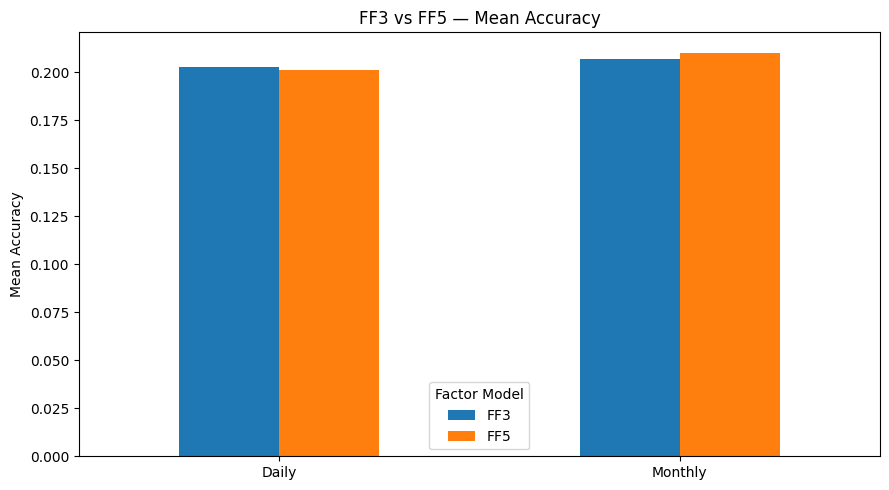

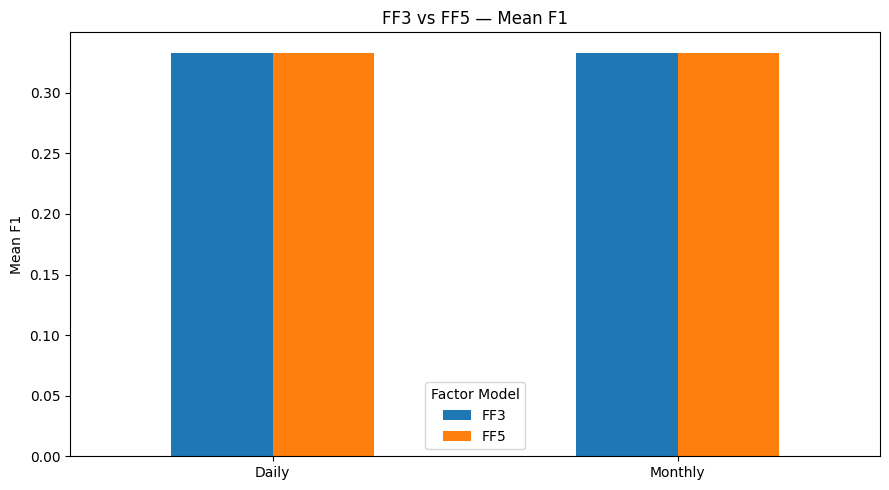

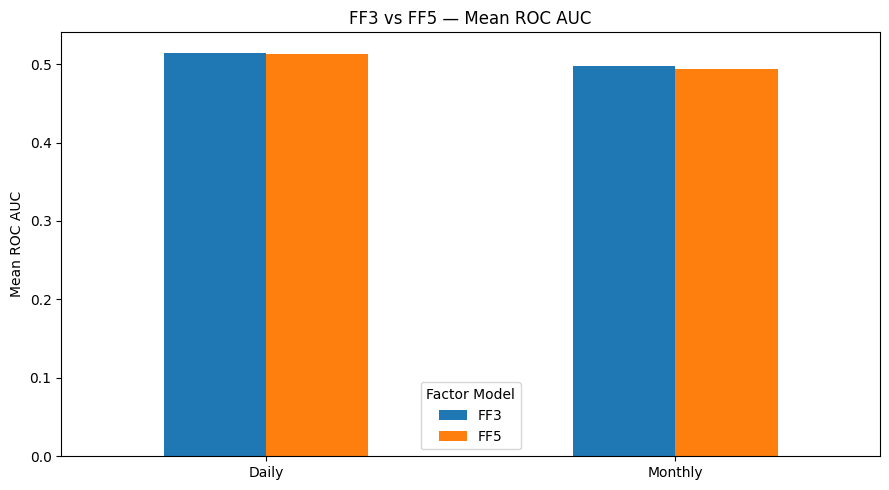

,Frequency,Factor Model,Mean_Annualized_Return,Mean_Sharpe,Mean_Max_Drawdown
0,Daily,FF3,0.1130,0.5681,-0.4546
1,Daily,FF5,0.0933,0.4783,-0.4367
2,Monthly,FF3,0.1236,0.7027,-0.3522
3,Monthly,FF5,0.1222,0.6565,-0.3146


In [10]:
if not classification_results.empty:
    factor_classification = (
        classification_results.groupby(["Frequency", "Factor Model"], as_index=False)
        .agg(
            Mean_Accuracy=("Accuracy", "mean"),
            Mean_F1=("F1", "mean"),
            Mean_ROC_AUC=("ROC_AUC", "mean"),
        )
    )
    factor_classification.to_csv(TABLE_DIR / "ff3_vs_ff5_classification.csv", index=False)
    display(factor_classification)

    for metric in ["Mean_Accuracy", "Mean_F1", "Mean_ROC_AUC"]:
        pivot = factor_classification.pivot(
            index="Frequency", columns="Factor Model", values=metric
        )
        ax = pivot.plot(kind="bar", figsize=(9, 5))
        ax.set_title(f"FF3 vs FF5 — {metric.replace('_', ' ')}")
        ax.set_xlabel("")
        ax.set_ylabel(metric.replace("_", " "))
        ax.tick_params(axis="x", rotation=0)
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / f"ff3_vs_ff5_{metric.lower()}.png", dpi=250)
        plt.show()

if not performance_results.empty:
    factor_portfolio = (
        performance_results.loc[~performance_results["Is Benchmark"]]
        .groupby(["Frequency", "Factor Model"], as_index=False)
        .agg(
            Mean_Annualized_Return=("Annualized Return", "mean"),
            Mean_Sharpe=("Sharpe Ratio", "mean"),
            Mean_Max_Drawdown=("Maximum Drawdown", "mean"),
        )
    )
    factor_portfolio.to_csv(TABLE_DIR / "ff3_vs_ff5_portfolio.csv", index=False)
    display(factor_portfolio)

## 9. Monthly vs daily robustness

In [11]:
if not classification_results.empty:
    frequency_classification = (
        classification_results.groupby("Frequency", as_index=False)
        .agg(
            Mean_Accuracy=("Accuracy", "mean"),
            Mean_F1=("F1", "mean"),
            Mean_ROC_AUC=("ROC_AUC", "mean"),
        )
    )
    frequency_classification.to_csv(TABLE_DIR / "monthly_vs_daily_classification.csv", index=False)
    display(frequency_classification)

if not performance_results.empty:
    frequency_portfolio = (
        performance_results.loc[~performance_results["Is Benchmark"]]
        .groupby("Frequency", as_index=False)
        .agg(
            Mean_Annualized_Return=("Annualized Return", "mean"),
            Mean_Sharpe=("Sharpe Ratio", "mean"),
            Mean_Max_Drawdown=("Maximum Drawdown", "mean"),
        )
    )
    frequency_portfolio.to_csv(TABLE_DIR / "monthly_vs_daily_portfolio.csv", index=False)
    display(frequency_portfolio)

,Frequency,Mean_Accuracy,Mean_F1,Mean_ROC_AUC
0,Daily,0.2020,0.3332,0.5139
1,Monthly,0.2086,0.3330,0.4957


,Frequency,Mean_Annualized_Return,Mean_Sharpe,Mean_Max_Drawdown
0,Daily,0.1031,0.5232,-0.4457
1,Monthly,0.1229,0.6796,-0.3334


## 10. Sharpe-ratio and annual-return charts

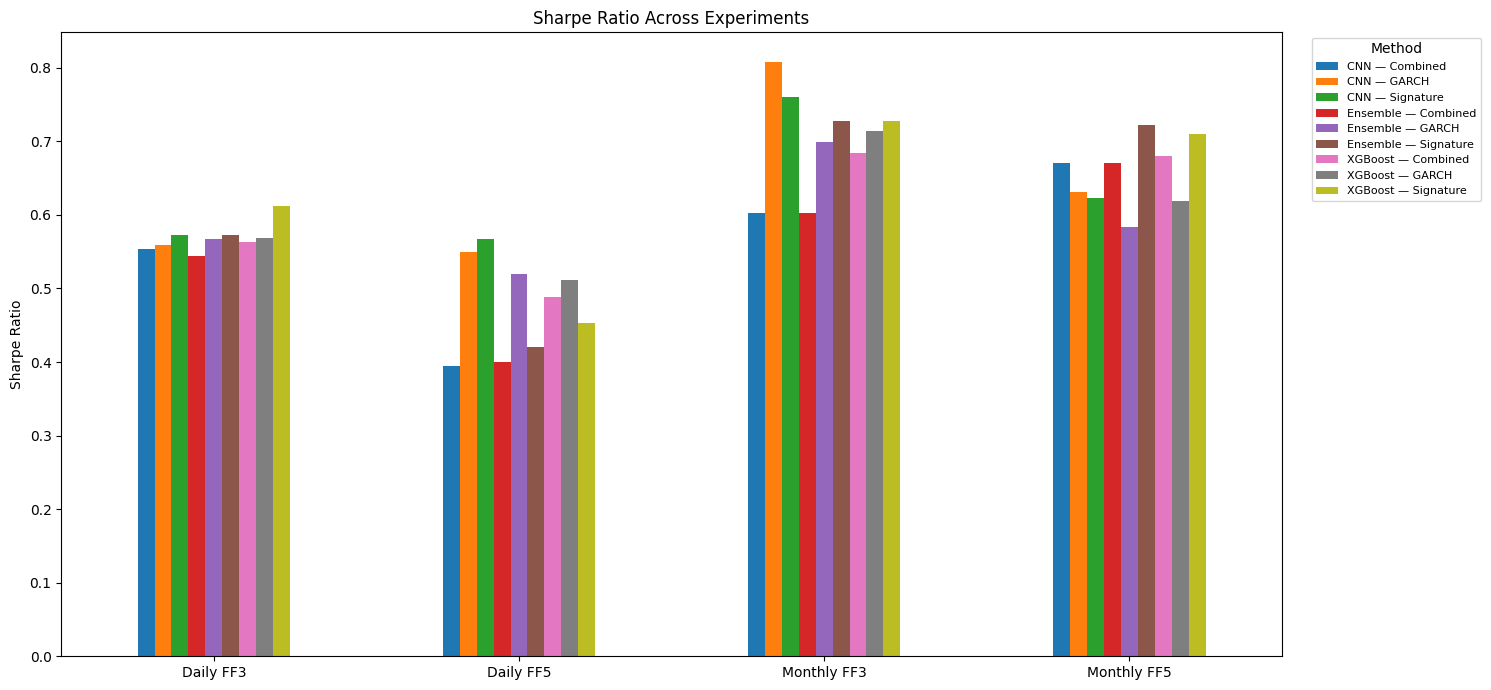

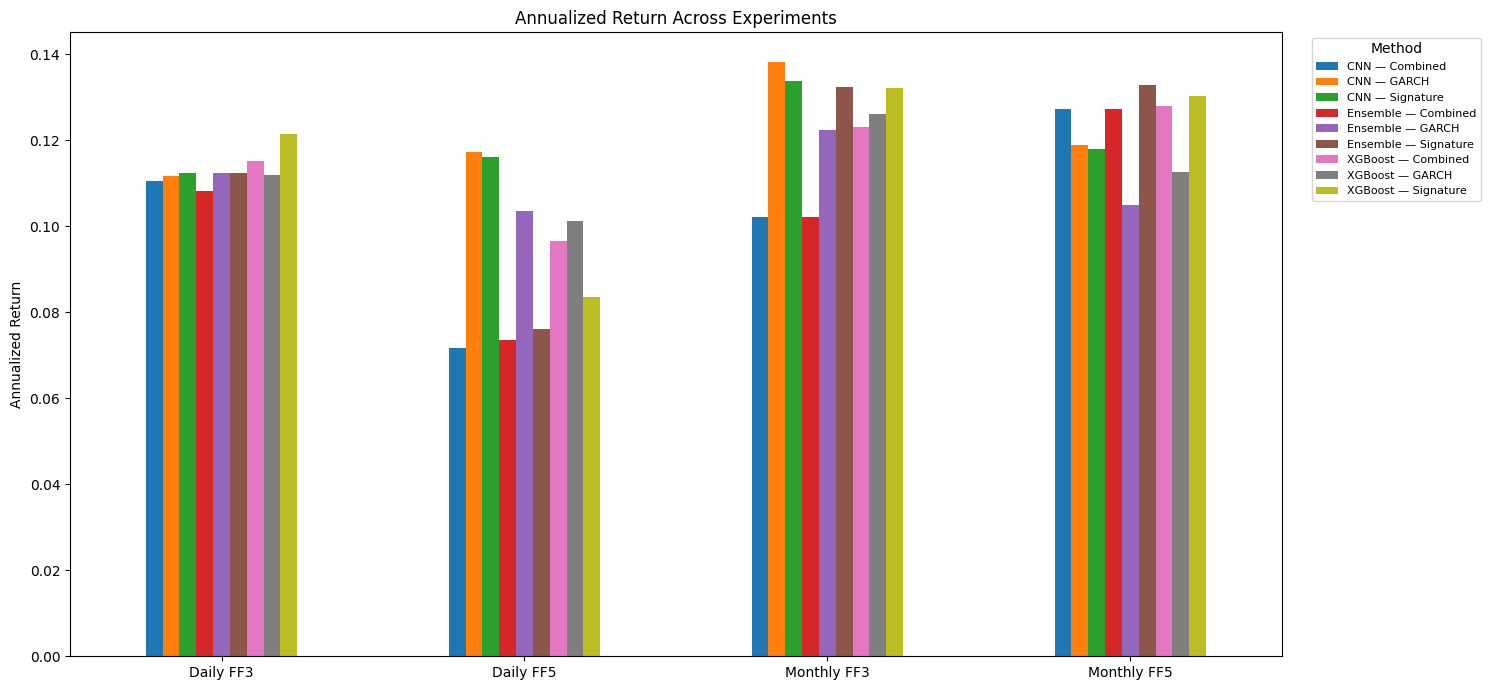

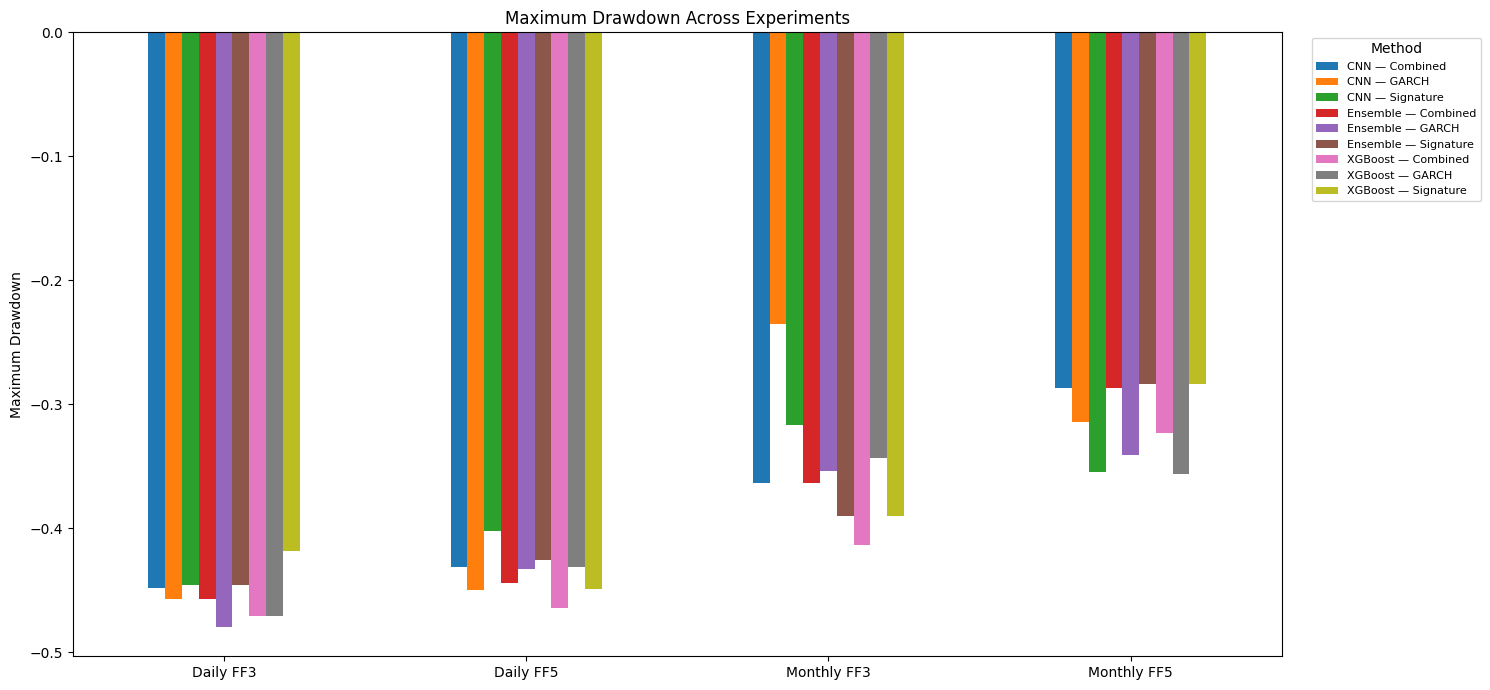

In [12]:
if not performance_results.empty:
    strategies_only = performance_results.loc[~performance_results["Is Benchmark"]].copy()
    strategies_only["Method"] = strategies_only["architecture"] + " — " + strategies_only["feature_type"]

    for metric, filename in [
        ("Sharpe Ratio", "strategy_sharpe_ratio.png"),
        ("Annualized Return", "strategy_annualized_return.png"),
        ("Maximum Drawdown", "strategy_maximum_drawdown.png"),
    ]:
        pivot = strategies_only.pivot_table(
            index="Dataset", columns="Method", values=metric, aggfunc="mean"
        )
        ax = pivot.plot(kind="bar", figsize=(15, 7))
        ax.set_title(f"{metric} Across Experiments")
        ax.set_xlabel("")
        ax.set_ylabel(metric)
        ax.tick_params(axis="x", rotation=0)
        ax.legend(title="Method", bbox_to_anchor=(1.02, 1), loc="upper left", fontsize=8)
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / filename, dpi=250, bbox_inches="tight")
        plt.show()

## 11. Cumulative wealth of each experiment’s best strategy

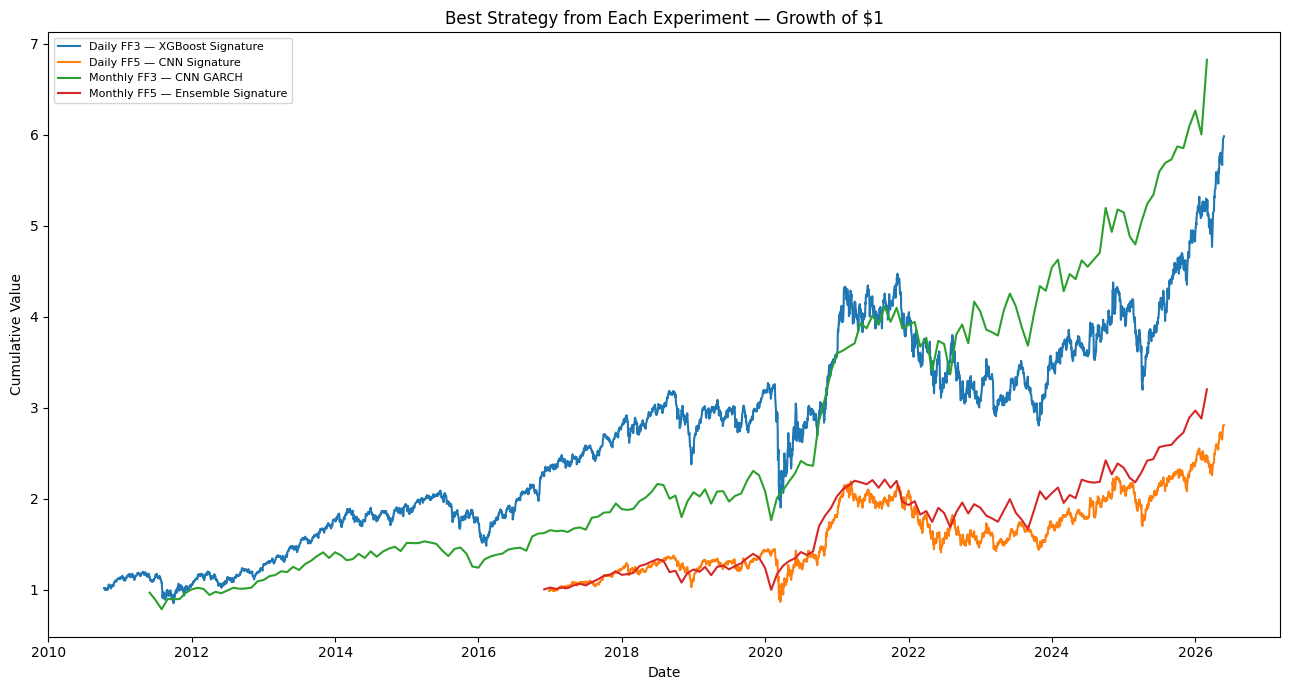

In [13]:
def strategy_filename(model_name):
    return model_name.lower().replace(" ", "_") + "_strategy.csv"

wealth_frames = []

if not performance_results.empty:
    best_rows = (
        performance_results.loc[~performance_results["Is Benchmark"]]
        .sort_values(["Sharpe Ratio", "Annualized Return"], ascending=False)
        .groupby("Experiment", as_index=False)
        .first()
    )

    plt.figure(figsize=(13, 7))

    for _, row in best_rows.iterrows():
        experiment = row["Experiment"]
        model = row["Model"]
        path = RESULT_ROOT / experiment / "backtest" / strategy_filename(model)

        if not path.exists():
            print("Missing strategy path:", path)
            continue

        strategy = pd.read_csv(path, parse_dates=["Date"])
        strategy["Experiment"] = experiment
        strategy["Dataset"] = EXPERIMENT_LABELS[experiment]
        strategy["Model"] = model
        wealth_frames.append(strategy)

        plt.plot(
            strategy["Date"],
            strategy["CumulativeValue"],
            label=f"{EXPERIMENT_LABELS[experiment]} — {model}",
        )

    plt.title("Best Strategy from Each Experiment — Growth of $1")
    plt.xlabel("Date")
    plt.ylabel("Cumulative Value")
    plt.legend(fontsize=8)
    plt.tight_layout()
    plt.savefig(FIGURE_DIR / "best_strategies_cumulative_wealth.png", dpi=250)
    plt.show()

all_best_wealth = pd.concat(wealth_frames, ignore_index=True) if wealth_frames else pd.DataFrame()
if not all_best_wealth.empty:
    all_best_wealth.to_csv(TABLE_DIR / "best_strategies_wealth_series.csv", index=False)

## 12. Compare each best strategy with its own benchmark

In [14]:
if not performance_results.empty:
    best_rows = (
        performance_results.loc[~performance_results["Is Benchmark"]]
        .sort_values(["Sharpe Ratio", "Annualized Return"], ascending=False)
        .groupby("Experiment", as_index=False)
        .first()
    )

    excess_rows = []
    for _, row in best_rows.iterrows():
        experiment = row["Experiment"]
        benchmark_row = performance_results.loc[
            (performance_results["Experiment"] == experiment)
            & performance_results["Is Benchmark"]
        ]

        if benchmark_row.empty:
            continue

        benchmark_row = benchmark_row.iloc[0]
        excess_rows.append({
            "Dataset": EXPERIMENT_LABELS[experiment],
            "Best Strategy": row["Model"],
            "Strategy Annualized Return": row["Annualized Return"],
            "Benchmark Annualized Return": benchmark_row["Annualized Return"],
            "Annualized Return Difference": row["Annualized Return"] - benchmark_row["Annualized Return"],
            "Strategy Sharpe": row["Sharpe Ratio"],
            "Benchmark Sharpe": benchmark_row["Sharpe Ratio"],
            "Sharpe Difference": row["Sharpe Ratio"] - benchmark_row["Sharpe Ratio"],
            "Strategy Maximum Drawdown": row["Maximum Drawdown"],
            "Benchmark Maximum Drawdown": benchmark_row["Maximum Drawdown"],
        })

    benchmark_comparison = pd.DataFrame(excess_rows)
    benchmark_comparison.to_csv(TABLE_DIR / "best_strategy_vs_benchmark.csv", index=False)
    display(benchmark_comparison)

,Dataset,Best Strategy,Strategy Annualized Return,Benchmark Annualized Return,Annualized Return Difference,Strategy Sharpe,Benchmark Sharpe,Sharpe Difference,Strategy Maximum Drawdown,Benchmark Maximum Drawdown
0,Daily FF3,XGBoost Signature,0.1216,0.1295,-0.0080,0.6126,0.6961,-0.0835,-0.4184,-0.4136
1,Daily FF5,CNN Signature,0.1162,0.1234,-0.0072,0.5674,0.6401,-0.0727,-0.4019,-0.4136
2,Monthly FF3,CNN GARCH,0.1382,0.1197,0.0185,0.8078,0.7122,0.0956,-0.2351,-0.3083
3,Monthly FF5,Ensemble Signature,0.1328,0.1203,0.0125,0.7217,0.6723,0.0494,-0.2840,-0.3083


## 13. Classification–investment relationship

### Correlation between predictive and investment metrics

,Accuracy,F1,ROC_AUC,Annualized Return,Sharpe Ratio,Maximum Drawdown
Accuracy,1.0000,-0.3886,-0.5214,0.3556,0.4849,0.5466
F1,-0.3886,1.0000,-0.1635,-0.1566,-0.1933,-0.2456
ROC_AUC,-0.5214,-0.1635,1.0000,-0.4398,-0.5803,-0.7916
Annualized Return,0.3556,-0.1566,-0.4398,1.0000,0.9559,0.5944
Sharpe Ratio,0.4849,-0.1933,-0.5803,0.9559,1.0000,0.7003
Maximum Drawdown,0.5466,-0.2456,-0.7916,0.5944,0.7003,1.0000


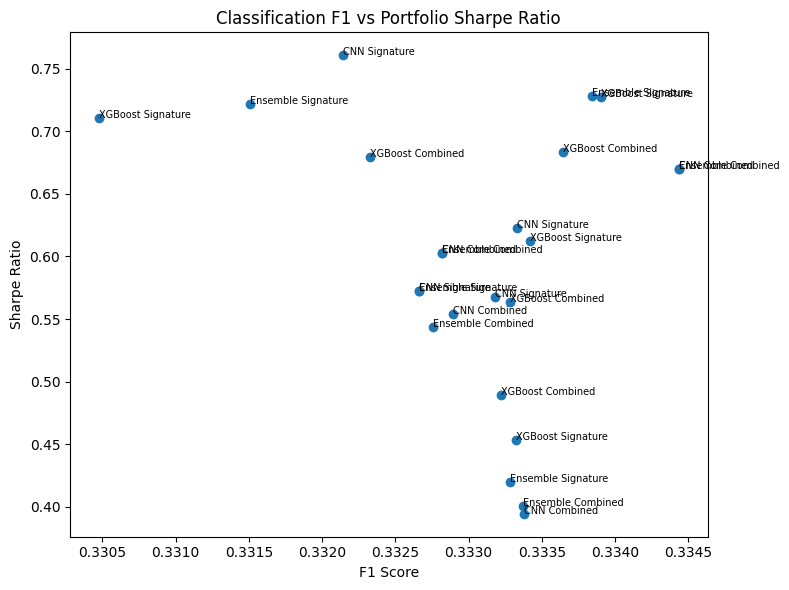

In [15]:
if not classification_results.empty and not performance_results.empty:
    cls_link = classification_results.copy()
    cls_link["Model_Key"] = cls_link["architecture"] + " " + cls_link["feature_type"]

    perf_link = performance_results.loc[~performance_results["Is Benchmark"]].copy()
    perf_link["Model_Key"] = perf_link["architecture"] + " " + perf_link["feature_type"]

    linked = cls_link.merge(
        perf_link,
        on=["Experiment", "Model_Key"],
        suffixes=("_classification", "_portfolio"),
    )

    selected = [
        "Experiment", "Dataset_classification", "Model_Key",
        "Accuracy", "F1", "ROC_AUC",
        "Annualized Return", "Sharpe Ratio", "Maximum Drawdown"
    ]
    selected = [c for c in selected if c in linked.columns]
    linked = linked[selected]
    linked.to_csv(TABLE_DIR / "classification_portfolio_link.csv", index=False)

    correlation_columns = [
        c for c in ["Accuracy", "F1", "ROC_AUC", "Annualized Return", "Sharpe Ratio", "Maximum Drawdown"]
        if c in linked.columns
    ]
    correlation = linked[correlation_columns].corr()
    correlation.to_csv(TABLE_DIR / "classification_portfolio_correlations.csv")

    display(Markdown("### Correlation between predictive and investment metrics"))
    display(correlation)

    if "F1" in linked.columns and "Sharpe Ratio" in linked.columns:
        plt.figure(figsize=(8, 6))
        plt.scatter(linked["F1"], linked["Sharpe Ratio"])
        for _, row in linked.iterrows():
            plt.annotate(row["Model_Key"], (row["F1"], row["Sharpe Ratio"]), fontsize=7)
        plt.xlabel("F1 Score")
        plt.ylabel("Sharpe Ratio")
        plt.title("Classification F1 vs Portfolio Sharpe Ratio")
        plt.tight_layout()
        plt.savefig(FIGURE_DIR / "f1_vs_sharpe.png", dpi=250)
        plt.show()

## 14. Automatically generated findings

In [16]:
summary_lines = []

if classification_results.empty:
    summary_lines.append("Classification results are not yet available for any complete experiment.")
else:
    best_cls = classification_results.sort_values(
        ["F1", "ROC_AUC", "Accuracy"], ascending=False
    ).iloc[0]
    summary_lines.append(
        f"The highest test F1 score is {best_cls['F1']:.4f}, produced by "
        f"{best_cls['model']} in {best_cls['Dataset']}."
    )

    feature_avg = classification_results.groupby("feature_type")["F1"].mean().sort_values(ascending=False)
    summary_lines.append(
        f"Across the available experiments, {feature_avg.index[0]} features have the highest "
        f"mean F1 score ({feature_avg.iloc[0]:.4f})."
    )

    arch_avg = classification_results.groupby("architecture")["F1"].mean().sort_values(ascending=False)
    summary_lines.append(
        f"Across the available experiments, {arch_avg.index[0]} has the highest "
        f"mean F1 score ({arch_avg.iloc[0]:.4f})."
    )

if performance_results.empty:
    summary_lines.append("Portfolio results are not yet available for any complete experiment.")
else:
    strategies = performance_results.loc[~performance_results["Is Benchmark"]]
    best_sharpe = strategies.sort_values("Sharpe Ratio", ascending=False).iloc[0]
    best_return = strategies.sort_values("Annualized Return", ascending=False).iloc[0]

    summary_lines.append(
        f"The highest strategy Sharpe ratio is {best_sharpe['Sharpe Ratio']:.4f}, produced by "
        f"{best_sharpe['Model']} in {best_sharpe['Dataset']}."
    )
    summary_lines.append(
        f"The highest annualized return is {best_return['Annualized Return']:.2%}, produced by "
        f"{best_return['Model']} in {best_return['Dataset']}."
    )

    feature_sharpe = strategies.groupby("feature_type")["Sharpe Ratio"].mean().sort_values(ascending=False)
    summary_lines.append(
        f"Across available backtests, {feature_sharpe.index[0]} features have the highest "
        f"mean Sharpe ratio ({feature_sharpe.iloc[0]:.4f})."
    )

summary_text = "\n".join(f"- {line}" for line in summary_lines)
display(Markdown("### Main findings\n" + summary_text))

with open(OUTPUT_DIR / "automated_findings.md", "w", encoding="utf-8") as file:
    file.write("# Automated Findings\n\n" + summary_text + "\n")

### Main findings
- The highest test F1 score is 0.3344, produced by CNN Combined in Monthly FF5.
- Across the available experiments, Combined features have the highest mean F1 score (0.3333).
- Across the available experiments, XGBoost has the highest mean F1 score (0.3331).
- The highest strategy Sharpe ratio is 0.8078, produced by CNN GARCH in Monthly FF3.
- The highest annualized return is 13.82%, produced by CNN GARCH in Monthly FF3.
- Across available backtests, Signature features have the highest mean Sharpe ratio (0.6224).

## 15. Export thesis-ready summary workbook

In [17]:
workbook_path = OUTPUT_DIR / "thesis_results_summary.xlsx"

with pd.ExcelWriter(workbook_path, engine="openpyxl") as writer:
    availability.to_excel(writer, sheet_name="Availability", index=False)

    if not classification_results.empty:
        classification_results.to_excel(writer, sheet_name="Classification_All", index=False)
        best_classification.to_excel(writer, sheet_name="Best_Classifier", index=False)
        overall_model_ranking.to_excel(writer, sheet_name="Model_Ranking", index=False)

    if not performance_results.empty:
        performance_results.to_excel(writer, sheet_name="Backtests_All", index=False)
        best_strategy.to_excel(writer, sheet_name="Best_Strategy", index=False)
        strategy_ranking.to_excel(writer, sheet_name="Strategy_Ranking", index=False)

    if "benchmark_comparison" in globals() and not benchmark_comparison.empty:
        benchmark_comparison.to_excel(writer, sheet_name="Vs_Benchmark", index=False)

    if "linked" in globals() and not linked.empty:
        linked.to_excel(writer, sheet_name="Prediction_vs_Return", index=False)

print("Saved workbook:", workbook_path.resolve())
print("Saved tables:", TABLE_DIR.resolve())
print("Saved figures:", FIGURE_DIR.resolve())

Saved workbook: C:\Users\kyler\Documents\VS_Code\Finance Code\ML using FAMA and FRENCH\results\robustness_analysis\thesis_results_summary.xlsx
Saved tables: C:\Users\kyler\Documents\VS_Code\Finance Code\ML using FAMA and FRENCH\results\robustness_analysis\tables
Saved figures: C:\Users\kyler\Documents\VS_Code\Finance Code\ML using FAMA and FRENCH\results\robustness_analysis\figures
